# Feature Selection Method Comparison

Each section covers one model. Within each section the same train/test split is used to rank features by four methods — SHAP, Gain, LIME, and Information Gain — then evaluates top-k (k = 1…10) features and plots a per-metric comparison.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import copy
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.feature_selection import mutual_info_regression
from lime.lime_tabular import LimeTabularExplainer

import lightgbm as lgb
import xgboost as xgb
import importlib
import bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison


/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
for mod in (bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison):
    importlib.reload(mod)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *
print("Modules reloaded.")

Modules reloaded.


### Data

In [3]:
seed = 666
os.makedirs(f"figures/uji_{seed}", exist_ok=True)
os.makedirs(f"shap_results/uji_{seed}", exist_ok=True)


img_path = f"figures/uji_{seed}"
shap_path = f"shap_results/uji_{seed}"

In [4]:
import pandas as pd
import numpy as np

train = pd.read_csv("data/UJIIndoorLoc/UJIndoorLoc/trainingData.csv")
test = pd.read_csv("data/UJIIndoorLoc/UJIndoorLoc/validationData.csv")

wap_cols = [c for c in train.columns if c.startswith("WAP")]

X_train = train[wap_cols].copy()
X_test = test[wap_cols].copy()

# Regression target: choose longitude or latitude
y_train = train["LONGITUDE"].copy()
y_test = test["LONGITUDE"].copy()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(19937, 520) (19937,)
(1111, 520) (1111,)


### Model Wrappers

In [5]:
# For UJIIndoorLoc:
# n ≈ 19,937 training samples
# p = 520 WAP features
# response = LONGITUDE or LATITUDE
# Do NOT use log-transform for y.

lgb_wrapper = create_model_wrapper(
    'lightgbm',
    params={
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.03,
        'max_depth': 7,
        'num_leaves': 63,
        'min_data_in_leaf': 30,
        'feature_fraction': 0.7,      # 0.7 × 520 ≈ 364 features per tree
        'bagging_fraction': 0.8,
        'bagging_freq': 1,
        'lambda_l1': 0.01,
        'lambda_l2': 1.0,
        'verbose': -1,
        'seed': seed,
        'num_threads': 4,
    },
    num_boost_round=300,
)

xgb_wrapper = create_model_wrapper(
    'xgboost',
    params={
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'eta': 0.03,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.7,      # 0.7 × 520 ≈ 364 features per tree
        'min_child_weight': 10,
        'reg_alpha': 0.01,
        'reg_lambda': 2.0,
        'tree_method': 'hist',
        'seed': seed,
        'nthread': 4,
    },
    num_boost_round=300,
)

rf_wrapper = create_model_wrapper(
    'sklearn',
    model_class=RandomForestRegressor,
    model_params={
        'n_estimators': 100,
        'random_state': seed,
        'max_depth': 10,
        'min_samples_leaf': 5,
        'max_features': 0.3,          # 0.3 × 520 ≈ 156 features per split
        'n_jobs': 6,
    },
    use_tree_explainer=True,
)

cb_wrapper = create_model_wrapper(
    'catboost',
    params={
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': seed,
        'learning_rate': 0.03,
        'depth': 6,
        'iterations': 300,
        'l2_leaf_reg': 5.0,
        'rsm': 0.7,                   # 0.7 × 520 ≈ 364 features
        'thread_count': 4,
        'verbose': False,
        'allow_writing_files': False,
    },
)

gb_wrapper = create_model_wrapper(
    'sklearn',
    model_class=GradientBoostingRegressor,
    model_params={
        'n_estimators': 150,
        'max_depth': 4,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'max_features': 0.5,          # 0.5 × 520 ≈ 260 features
        'min_samples_leaf': 10,
        'random_state': seed,
    },
    use_tree_explainer=True,
)

ridge_wrapper = create_model_wrapper(
    'sklearn',
    model_class=Ridge,
    model_params={
        'alpha': 10.0,                # stronger than 1.0, but not too large
        'random_state': seed,
    },
    use_linear_explainer=True,
    use_tree_explainer=False,
)

MODELS = {
    'LightGBM':         lgb_wrapper,
    'XGBoost':          xgb_wrapper,
    'RandomForest':     rf_wrapper,
    'CatBoost':         cb_wrapper,
    'GradientBoosting': gb_wrapper,
    'Ridge':            ridge_wrapper,
}

### Helper Functions

In [6]:
def _clone_wrapper(wrapper, input_dim=None):
    if isinstance(wrapper, XGBoostWrapper):
        return XGBoostWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, LightGBMWrapper):
        return LightGBMWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, SklearnWrapper):
        return SklearnWrapper(
            model_class=wrapper.model_class,
            model_params=wrapper.model_params.copy(),
            use_tree_explainer=wrapper.use_tree_explainer,
            use_linear_explainer=wrapper.use_linear_explainer,
        )
    if isinstance(wrapper, CatBoostWrapper):
        return CatBoostWrapper(params=wrapper.params.copy(), num_boost_round=getattr(wrapper, 'num_boost_round', 100))
    return copy.deepcopy(wrapper)


def _predict(wrapper, X):
    if isinstance(wrapper, XGBoostWrapper):
        return wrapper.model.predict(xgb.DMatrix(X, enable_categorical=True))
    if isinstance(wrapper, LightGBMWrapper):
        return wrapper.model.predict(X)
    if isinstance(wrapper, (CatBoostWrapper, SklearnWrapper)):
        return wrapper.model.predict(X)
    raise TypeError(f'Unknown wrapper: {type(wrapper)}')


def get_shap_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
        sv = w.compute_shap(X_tr, task='regression')
    importance = np.abs(sv).sum(axis=tuple(range(sv.ndim - 1)))
    return (
        pd.DataFrame({'feature': X_tr.columns, 'importance': importance})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_gain_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    if isinstance(w, LightGBMWrapper):
        imp = w.model.feature_importance(importance_type='gain').astype(float)
    elif isinstance(w, XGBoostWrapper):
        scores = w.model.get_score(importance_type='gain')
        imp = np.array([scores.get(f, 0.0) for f in X_tr.columns], dtype=float)
    elif isinstance(w, CatBoostWrapper):
        imp = np.array(w.model.get_feature_importance(), dtype=float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'feature_importances_'):
        imp = w.model.feature_importances_.astype(float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'coef_'):
        imp = np.abs(w.model.coef_).ravel().astype(float)
    else:
        return None
    return (
        pd.DataFrame({'feature': X_tr.columns.tolist(), 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_lime_ranking(wrapper, X_tr, y_tr, n_samples=10, num_features=50,
                     lime_background=500):
    """lime_background: max rows used as LIME background — capped to avoid OOM
    with high-dimensional data (150k features × 16k rows = 9 GB dense)."""
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    feat_names = X_tr.columns.tolist()

    # subsample background to avoid materialising the full dense matrix
    bg_idx = np.random.RandomState(0).choice(
        len(X_tr), min(lime_background, len(X_tr)), replace=False
    )
    X_bg  = X_tr.iloc[bg_idx].values.astype(float)   # (lime_background, n_feat)
    X_arr = X_tr.values.astype(float)                 # full dense — only used for explain_instance

    def _pred(arr, _w=w):
        return _predict(_w, pd.DataFrame(arr, columns=feat_names))

    explainer = LimeTabularExplainer(
        X_bg, feature_names=feat_names,
        mode='regression', random_state=42,
    )
    idx = np.random.RandomState(42).choice(len(X_arr), min(n_samples, len(X_arr)), replace=False)
    imp = np.zeros(len(feat_names))
    for i in idx:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            exp = explainer.explain_instance(X_arr[i], _pred, num_features=num_features)
        for fi, w_val in exp.local_exp[0]:
            imp[fi] += abs(w_val)
    imp /= len(idx)
    return (
        pd.DataFrame({'feature': feat_names, 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def evaluate_topk(wrapper, ranking_df, X_tr, X_te, y_tr, y_te, k_values=range(1, 11)):
    results = {'rmse': [], 'mae': [], 'mape': []}
    for k in k_values:
        selected = ranking_df['feature'].head(k).tolist()
        selected_set = set(selected)
        feats = [c for c in X_tr.columns if c in selected_set]

        try:
            w = _clone_wrapper(wrapper, input_dim=len(feats))
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                w.fit(X_tr[feats], y_tr)
                y_pred = _predict(w, X_te[feats])
            y_te_arr = np.asarray(y_te).ravel()
            results['rmse'].append(np.sqrt(mean_squared_error(y_te_arr, y_pred)))
            results['mae'].append(mean_absolute_error(y_te_arr, y_pred))
            results['mape'].append(np.mean(np.abs((y_te_arr - y_pred) / np.abs(y_te_arr))) * 100)
        except Exception:
            for m in results:
                results[m].append(float('nan'))
    return results


def plot_comparison(model_name, all_results, k_values=list(range(1, 11))):
    metric_keys   = ['rmse', 'mae', 'mape'    ]
    metric_titles = ['RMSE', 'MAE', 'MAPE (%)']
    method_styles = {
        'SHAP':   dict(color='steelblue',  linestyle='-',  marker='o'),
        'Gain':   dict(color='darkorange', linestyle='--', marker='s'),
        'MDI':    dict(color='darkorange', linestyle='--', marker='s'),
        'Native': dict(color='darkorange', linestyle='--', marker='s'),
        '|Coef|': dict(color='darkorange', linestyle='--', marker='s'),
        'LIME':   dict(color='green',      linestyle='-.', marker='^'),
        'IG':     dict(color='crimson',    linestyle=':',  marker='D'),
        'Robust': dict(color='purple',     linestyle='-',  marker='X'),
    }
    fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True)
    for ax, key, title in zip(axes, metric_keys, metric_titles):
        for method, res in all_results.items():
            if res is None:
                continue
            ax.plot(k_values, res[key], linewidth=2.0, markersize=6,
                    label=method, **method_styles.get(method, {}))
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.set_xlabel('k (number of features)', fontsize=14)
        ax.set_ylabel(title, fontsize=14)
        ax.set_xticks(k_values)
        ax.tick_params(axis='both', labelsize=11)
        ax.legend(fontsize=10, loc='upper right')
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    os.makedirs(f"figures/uji_{seed}", exist_ok=True)
    fig.savefig(f"figures/uji_{seed}/uji_{model_name}_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

In [7]:
def plot_comparison_bar(model_name, all_results, k_values=list(range(1, 11))):
    """Bar chart: mean over k with std error bars, one panel per metric."""
    metric_keys   = ['rmse', 'mae', 'mape'    ]
    metric_titles = ['RMSE', 'MAE', 'MAPE (%)']
    method_colors = {
        'SHAP':   'steelblue',
        'Gain':   'darkorange',
        'PVC':    'darkorange',
        'MDI':    'darkorange',
        'Native': 'darkorange',
        '|Coef|': 'darkorange',
        'LIME':   'green',
        'IG':     'crimson',
        'RoSHAP': 'purple',
    }

    methods = [m for m, r in all_results.items() if r is not None]
    colors  = [method_colors.get(m, 'gray') for m in methods]
    x       = np.arange(len(methods))
    bar_w   = 0.6

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    for ax, key, title in zip(axes, metric_keys, metric_titles):
        means = [np.nanmean(all_results[m][key]) for m in methods]
        stds  = [np.nanstd(all_results[m][key], ddof=0) for m in methods]

        valid = [not np.isnan(v) for v in means]
        x_plot       = x[np.array(valid)]
        means_plot   = [v for v, ok in zip(means,   valid) if ok]
        stds_plot    = [v for v, ok in zip(stds,    valid) if ok]
        colors_plot  = [c for c, ok in zip(colors,  valid) if ok]
        methods_plot = [m for m, ok in zip(methods, valid) if ok]

        bars = ax.bar(x_plot, means_plot, width=bar_w, color=colors_plot,
                      edgecolor='white', linewidth=0.8,
                      yerr=stds_plot, capsize=4,
                      error_kw=dict(elinewidth=1.2, ecolor='black', capthick=1.2))
        ax.set_title(title, fontweight='bold', fontsize=22)
        ax.set_ylabel(title, fontsize=18)
        ax.set_xticks(x_plot)
        ax.set_xticklabels(methods_plot, fontsize=20, rotation=30, ha='right')
        ax.tick_params(axis='y', labelsize=16)
        ax.grid(axis='y', alpha=0.3)
        ax.set_axisbelow(True)

        if means_plot:
            y_lo = 0
            y_hi = max(m + s for m, s in zip(means_plot, stds_plot)) * 1.1 + 0.01
            ax.set_ylim(y_lo, y_hi)
            for bar, v, s in zip(bars, means_plot, stds_plot):
                ax.text(bar.get_x() + bar.get_width() / 2, v + s + (y_hi - y_lo) * 0.01,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=16)

    plt.tight_layout()
    os.makedirs(f"figures/uji_{seed}", exist_ok=True)
    fig.savefig(f"figures/uji_{seed}/uji_{model_name}_bar_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

### Information Gain Ranking (computed once, model-agnostic)

In [8]:
print('Computing Information Gain scores...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ig_scores = mutual_info_regression(X_train, y_train, random_state=42)

ig_ranking = (
    pd.DataFrame({'feature': X_train.columns, 'importance': ig_scores})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
print('Top-10 IG features:')
ig_ranking.head(10)


Computing Information Gain scores...


KeyboardInterrupt: 

---
## LightGBM

### LightGBM — SHAP

In [23]:
print('Computing SHAP ranking for LightGBM...')
lightgbm_shap = get_shap_ranking(MODELS['LightGBM'], X_train, y_train)
print('Top-10:')
lightgbm_shap.head(10)


Computing SHAP ranking for LightGBM...
Top-10:


,feature,importance
0,WAP156,261908.573724
1,WAP155,244209.095319
2,WAP161,161841.015366
3,WAP052,129808.616811
4,WAP501,127197.719855
5,WAP051,123177.241962
6,WAP496,120179.977007
7,WAP087,110372.249712
8,WAP118,96386.825945
9,WAP162,78161.022335


### LightGBM — Gain

In [24]:
print('Computing Gain ranking for LightGBM...')
lightgbm_gain = get_gain_ranking(MODELS['LightGBM'], X_train, y_train)
if lightgbm_gain is not None:
    print('Top-10:')
    display(lightgbm_gain.head(10))
else:
    print('Gain not supported for LightGBM')


Computing Gain ranking for LightGBM...
Top-10:


,feature,importance
0,WAP156,6.084247e+08
1,WAP155,5.282438e+08
2,WAP161,3.651012e+08
3,WAP051,3.598187e+08
4,WAP496,2.069315e+08
5,WAP052,1.737170e+08
6,WAP501,1.526807e+08
7,WAP162,1.242508e+08
8,WAP118,1.217878e+08
9,WAP087,1.120845e+08


### LightGBM — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [25]:
print('Computing LIME ranking for LightGBM...')
lightgbm_lime = get_lime_ranking(
    MODELS['LightGBM'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
lightgbm_lime.head(10)

Computing LIME ranking for LightGBM...
Top-10:


,feature,importance
0,WAP248,1.817584
1,WAP343,0.000000
2,WAP344,0.000000
3,WAP345,0.000000
4,WAP346,0.000000
5,WAP347,0.000000
6,WAP348,0.000000
7,WAP326,0.000000
8,WAP350,0.000000
9,WAP351,0.000000


### LightGBM — Robust

In [69]:
# top60 = lightgbm_shap['feature'].head(60).tolist()

In [70]:
lgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,  
    y=y_train,
    inner_variance="permutation",
    task="regression",
    n_bootstrap=500,  
    b_model=2, 
    zero_tol=0,
    model_wrapper=lgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):   5%|▌         | 25/500 [00:36<16:34,  2.09s/it] /home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Bootstrap repeats (feature-agg):   5%|▌         | 26/500 [00:37<13:16,  1.68s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Bootstrap repeats (feature-agg):  15%|█▍        | 73/500 [01:34<12:13,  1.72s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be cau

In [26]:
filepath = shap_path + "/lgb_uji.parquet"
# pd.concat(lgb_boot_unscreen, ignore_index=True).to_parquet(
#     filepath, index=False, compression="zstd"
# )
# print("Saved!")

df_all = pd.read_parquet(filepath)
lgb_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(lgb_boot_unscreen)} bootstrap results")

Loaded 500 bootstrap results


In [27]:
lgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lgb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [28]:
tmp = lgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(100, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

lightgbm_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
lightgbm_robust.head(10)


,feature,importance
Rank,,
1,WAP155,326286.576263
2,WAP156,297067.833686
3,WAP051,200738.588493
4,WAP161,140333.258050
5,WAP496,137274.066409
6,WAP501,134959.067939
7,WAP052,123712.319208
8,WAP087,119588.069250
9,WAP118,114446.471439


### LightGBM — Evaluation & Comparison

In [29]:
k_values = list(range(1,101,10))

print('Evaluating LightGBM — SHAP...')
lightgbm_res_shap = evaluate_topk(MODELS['LightGBM'], lightgbm_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LightGBM — Gain...')
lightgbm_res_gain = evaluate_topk(MODELS['LightGBM'], lightgbm_gain, X_train, X_test, y_train, y_test, k_values) if lightgbm_gain is not None else None

print('Evaluating LightGBM — LIME...')
lightgbm_res_lime = evaluate_topk(MODELS['LightGBM'], lightgbm_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LightGBM — IG...')
lightgbm_res_ig = evaluate_topk(MODELS['LightGBM'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LightGBM — Robust Bootstrap...')
lightgbm_res_robust = evaluate_topk(MODELS['LightGBM'], lightgbm_robust, X_train, X_test, y_train, y_test, k_values)

Evaluating LightGBM — SHAP...
Evaluating LightGBM — Gain...
Evaluating LightGBM — LIME...
Evaluating LightGBM — IG...
Evaluating LightGBM — Robust Bootstrap...


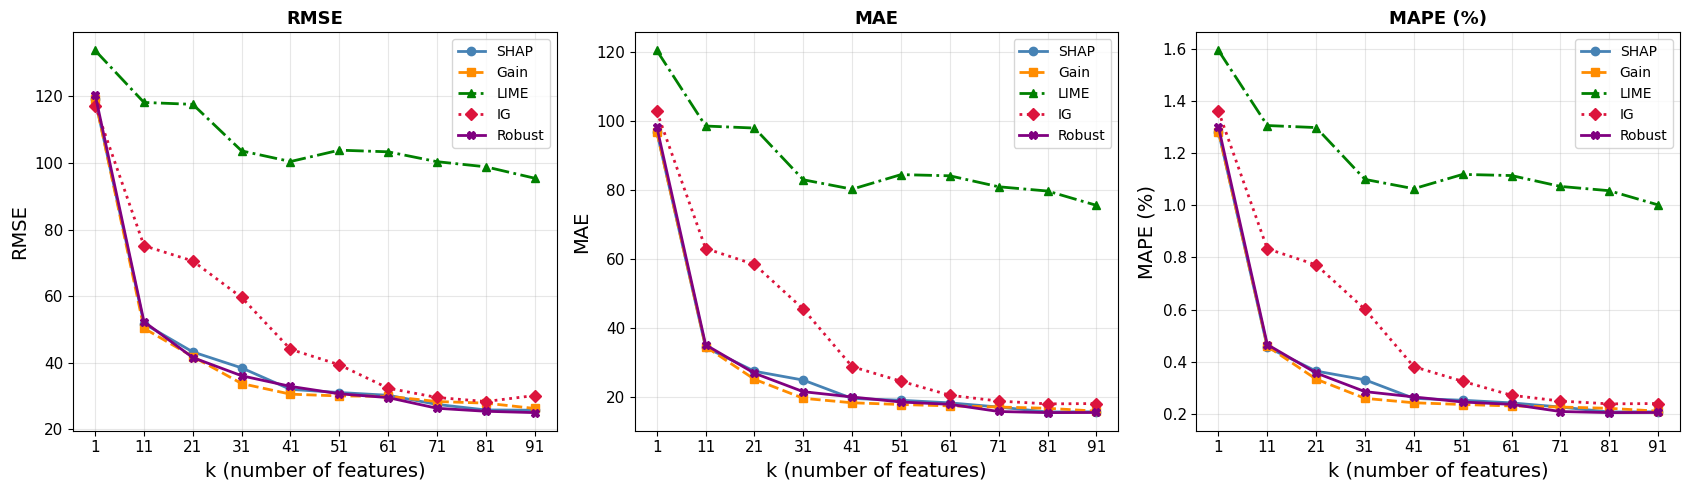

In [75]:
plot_comparison(
    'LightGBM',
    {'SHAP': lightgbm_res_shap, 'Gain': lightgbm_res_gain,
     'LIME': lightgbm_res_lime, 'IG':   lightgbm_res_ig, 'Robust': lightgbm_res_robust},
    k_values,
)

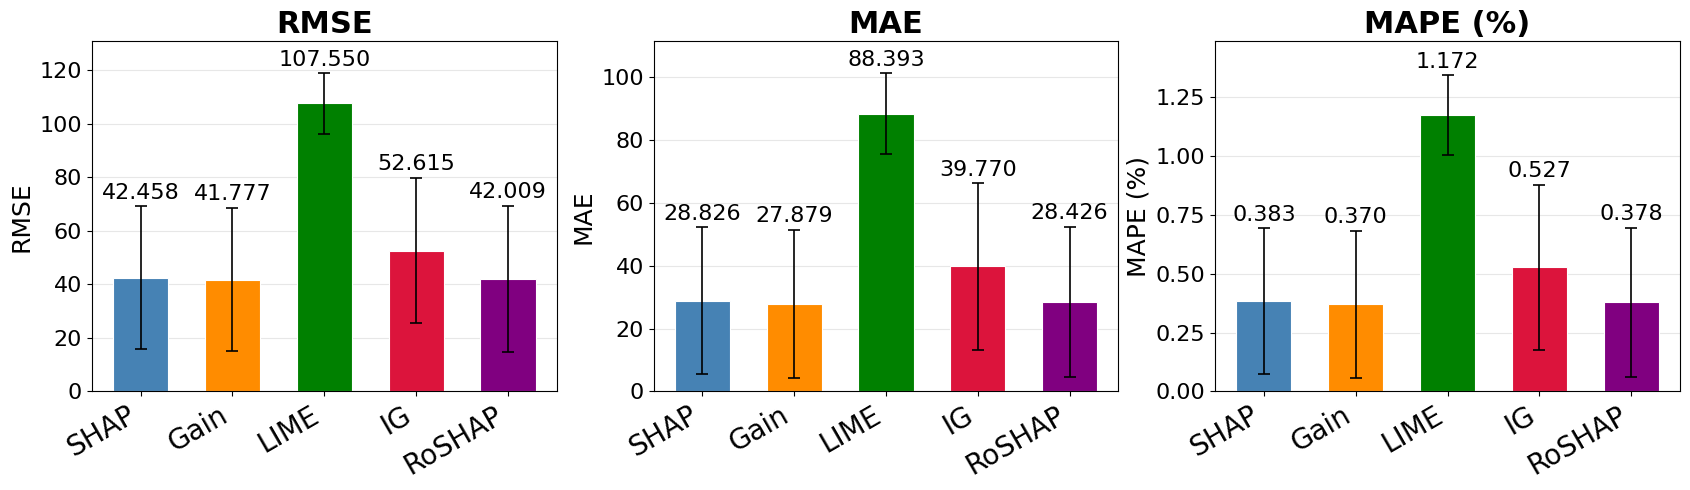

In [30]:
plot_comparison_bar(
    'LightGBM',
    {'SHAP': lightgbm_res_shap, 'Gain': lightgbm_res_gain,
     'LIME': lightgbm_res_lime, 'IG':   lightgbm_res_ig, 'RoSHAP': lightgbm_res_robust},
    k_values,
)

---
## XGBoost

### XGBoost — SHAP

In [9]:
print('Computing SHAP ranking for XGBoost...')
xgboost_shap = get_shap_ranking(MODELS['XGBoost'], X_train, y_train)
print('Top-10:')
xgboost_shap.head(10)

Computing SHAP ranking for XGBoost...
Top-10:


,feature,importance
0,WAP155,250657.671875
1,WAP156,250389.718750
2,WAP501,133911.984375
3,WAP052,133106.703125
4,WAP051,124816.906250
5,WAP496,116367.085938
6,WAP161,114586.273438
7,WAP162,104210.453125
8,WAP087,99733.359375
9,WAP118,87941.906250


### XGBoost — Gain

In [10]:
print('Computing Gain ranking for XGBoost...')
xgboost_gain = get_gain_ranking(MODELS['XGBoost'], X_train, y_train)
if xgboost_gain is not None:
    print('Top-10:')
    display(xgboost_gain.head(10))
else:
    print('Gain not supported for XGBoost')


Computing Gain ranking for XGBoost...
Top-10:


,feature,importance
0,WAP156,2.406191e+06
1,WAP155,1.956217e+06
2,WAP051,1.481344e+06
3,WAP161,1.474566e+06
4,WAP162,1.017085e+06
5,WAP052,9.572960e+05
6,WAP118,9.306881e+05
7,WAP496,7.995915e+05
8,WAP502,6.867842e+05
9,WAP501,5.993883e+05


### XGBoost — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [11]:
print('Computing LIME ranking for XGBoost...')
xgboost_lime = get_lime_ranking(
    MODELS['XGBoost'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
xgboost_lime.head(10)


Computing LIME ranking for XGBoost...
Top-10:


,feature,importance
0,WAP248,1.696995
1,WAP343,0.000000
2,WAP344,0.000000
3,WAP345,0.000000
4,WAP346,0.000000
5,WAP347,0.000000
6,WAP348,0.000000
7,WAP326,0.000000
8,WAP350,0.000000
9,WAP351,0.000000


### XGBoost — Robust

In [12]:
top60 = xgboost_shap['feature'].head(60).tolist()

In [30]:
xgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="regression",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=xgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [12:24<00:00,  1.49s/it]


In [9]:
filepath = shap_path + "/xgb_uji.parquet"
# pd.concat(xgb_boot_unscreen, ignore_index=True).to_parquet(
#     filepath, index=False, compression="zstd"
# )
# print("Saved!")

df_all = pd.read_parquet(filepath)
xgb_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(xgb_boot_unscreen)} bootstrap results")

Loaded 500 bootstrap results


In [10]:
xgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=xgb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [11]:
tmp = xgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(100, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

xgboost_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
xgboost_robust.head(10)


,feature,importance
Rank,,
1,WAP155,280449.564222
2,WAP156,277731.527054
3,WAP051,178881.179523
4,WAP496,136010.756014
5,WAP161,134342.609287
6,WAP501,132761.634284
7,WAP052,127975.243918
8,WAP087,115329.581946
9,WAP118,110437.675512


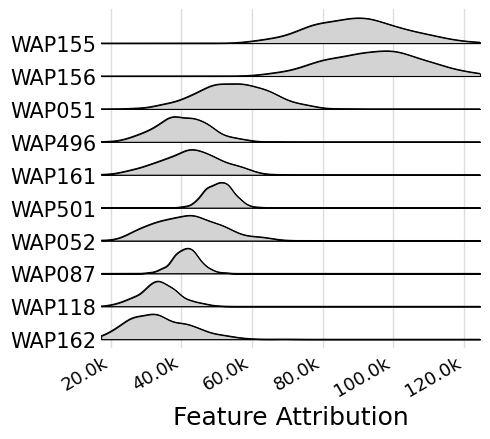

In [12]:
top_k = 10
agg_col = "sum_abs_shap"
top_features = xgboost_robust["feature"].astype(str).head(top_k).tolist()

box_rows = []
for b, res in enumerate(xgb_boot_unscreen):
    part = res.loc[:, ["feature", agg_col]].copy()
    part["feature"] = part["feature"].astype(str)
    part = part[part["feature"].isin(top_features)]
    part["bootstrap_id"] = b
    box_rows.append(part)

box_df = pd.concat(box_rows, ignore_index=True)
box_df = box_df.dropna(subset=[agg_col])
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.ticker import FuncFormatter

plot_data = [
    box_df.loc[box_df["feature"] == f, agg_col].dropna().to_numpy()
    for f in top_features
]

all_vals = np.concatenate(plot_data)
x_min = np.nanpercentile(all_vals, 0.1)
x_max = np.nanpercentile(all_vals, 99.9)
x_grid = np.linspace(x_min, x_max, 500)

spacing = 0.55
scale = 0.42

fig, ax = plt.subplots(figsize=(5, max(4.5, 0.38 * len(top_features))))

ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(axis="x", color="#DDDDDD", linewidth=1.0, zorder=0)

for i in range(len(top_features)):
    feature = top_features[i]
    vals = plot_data[i]
    y_base = (len(top_features) - 1 - i) * spacing

    if len(vals) > 2 and np.std(vals) > 0:
        kde = gaussian_kde(vals)
        dens = kde(x_grid)
        dens = dens / dens.max() * scale
    else:
        dens = np.zeros_like(x_grid)

    ax.fill_between(
        x_grid,
        y_base,
        y_base + dens,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.8,
        alpha=1.0,
        zorder=10 + i,
    )

    ax.plot(
        x_grid,
        y_base + dens,
        color="black",
        linewidth=0.8,
        zorder=11 + i,
    )

    ax.hlines(
        y_base,
        x_min,
        x_max,
        color="black",
        linewidth=0.5,
        zorder=12 + i,
    )

ax.set_yticks([(len(top_features) - 1 - i) * spacing for i in range(len(top_features))])
ax.set_yticklabels(top_features, fontsize=13)

ax.set_xlabel(r"Feature Attribution", fontsize=18)
ax.set_ylabel("")

ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.15, (len(top_features) - 1) * spacing + scale + 0.15)


ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _pos: f'{x / 1000:.1f}k')
    )

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", labelsize=13, length=0)
ax.tick_params(axis="y", labelsize=15, length=0)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

### XGBoost — Evaluation & Comparison

In [20]:
k_values = [10,20,30,40,50, 60,70,80,90,100]

print('Evaluating XGBoost — SHAP...')
xgboost_res_shap = evaluate_topk(MODELS['XGBoost'], xgboost_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating XGBoost — Gain...')
xgboost_res_gain = evaluate_topk(MODELS['XGBoost'], xgboost_gain, X_train, X_test, y_train, y_test, k_values) if xgboost_gain is not None else None

print('Evaluating XGBoost — LIME...')
xgboost_res_lime = evaluate_topk(MODELS['XGBoost'], xgboost_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating XGBoost — IG...')
xgboost_res_ig = evaluate_topk(MODELS['XGBoost'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating XGBoost — Robust Bootstrap...')
xgboost_res_robust = evaluate_topk(MODELS['XGBoost'], xgboost_robust, X_train, X_test, y_train, y_test, k_values)

Evaluating XGBoost — SHAP...
Evaluating XGBoost — Gain...
Evaluating XGBoost — LIME...
Evaluating XGBoost — IG...
Evaluating XGBoost — Robust Bootstrap...


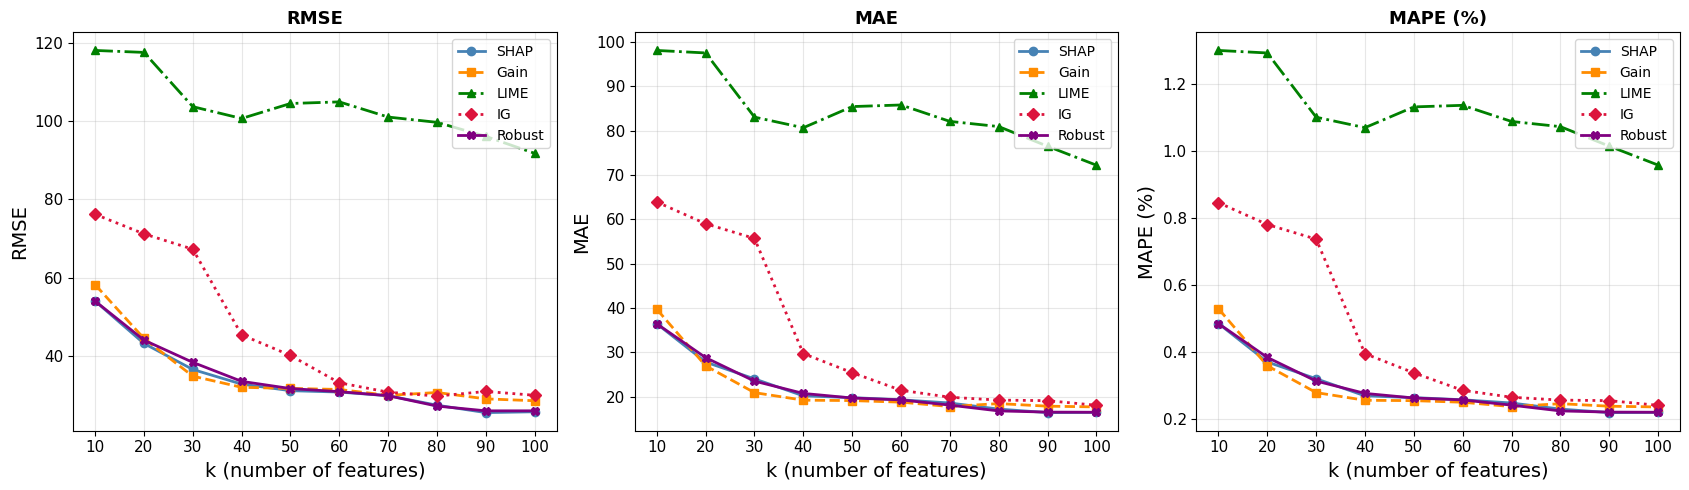

In [49]:
plot_comparison(
    'XGBoost',
    {'SHAP': xgboost_res_shap, 'Gain': xgboost_res_gain,
     'LIME': xgboost_res_lime, 'IG':   xgboost_res_ig, 'Robust': xgboost_res_robust},
    k_values,
)

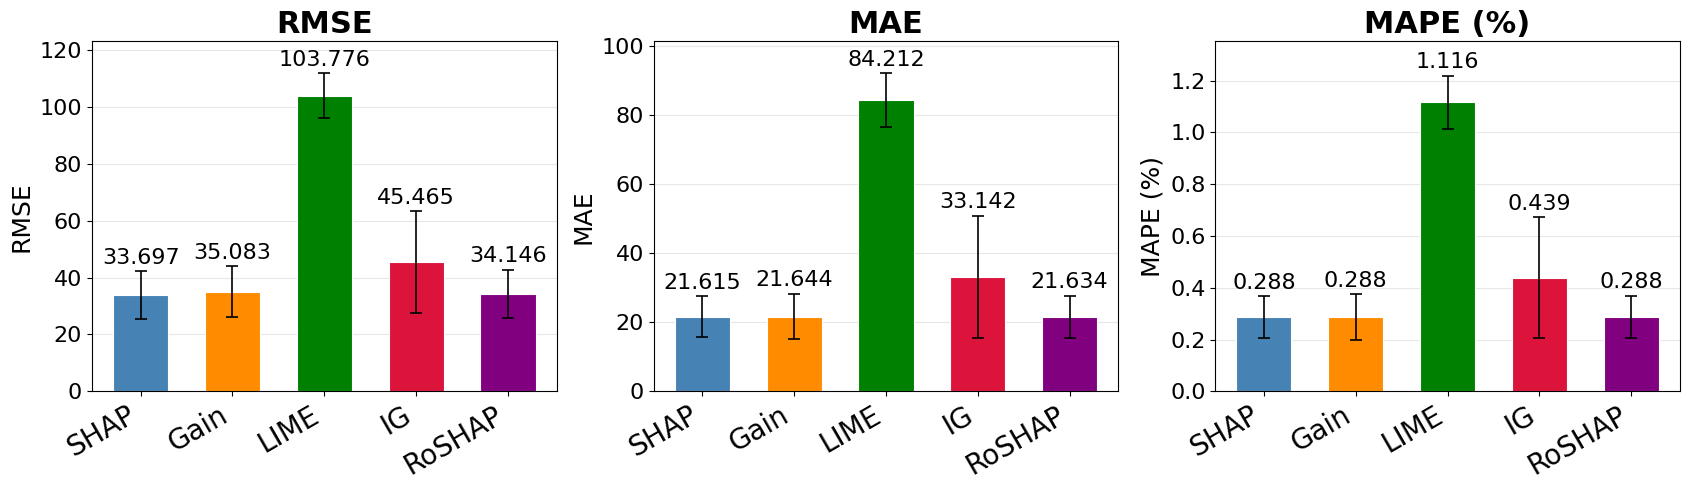

In [22]:
plot_comparison_bar(
    'XGBoost', 
    {'SHAP': xgboost_res_shap, 'Gain': xgboost_res_gain, 
     'LIME': xgboost_res_lime, 'IG': xgboost_res_ig, 'RoSHAP': xgboost_res_robust}, k_values
)

---
## RandomForest

### RandomForest — SHAP

In [9]:
print('Computing SHAP ranking for RandomForest...')
randomforest_shap = get_shap_ranking(MODELS['RandomForest'], X_train, y_train)
print('Top-10:')
randomforest_shap.head(10)

Computing SHAP ranking for RandomForest...
Top-10:


,feature,importance
0,WAP156,299402.867671
1,WAP155,266795.736609
2,WAP496,259628.860014
3,WAP051,194491.585658
4,WAP052,156282.211371
5,WAP118,142453.577136
6,WAP087,138938.867397
7,WAP501,126017.657403
8,WAP013,113958.607724
9,WAP162,105419.872136


### RandomForest — Gain

In [78]:
print('Computing Gain ranking for RandomForest...')
randomforest_gain = get_gain_ranking(MODELS['RandomForest'], X_train, y_train)
if randomforest_gain is not None:
    print('Top-10:')
    display(randomforest_gain.head(10))
else:
    print('Gain not supported for RandomForest')


Computing Gain ranking for RandomForest...
Top-10:


,feature,importance
0,WAP156,0.124565
1,WAP155,0.101674
2,WAP051,0.071244
3,WAP496,0.070108
4,WAP052,0.054411
5,WAP161,0.049674
6,WAP013,0.038084
7,WAP162,0.035982
8,WAP501,0.034131
9,WAP087,0.029814


### RandomForest — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [79]:
print('Computing LIME ranking for RandomForest...')
randomforest_lime = get_lime_ranking(
    MODELS['RandomForest'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
randomforest_lime.head(10)

Computing LIME ranking for RandomForest...
Top-10:


,feature,importance
0,WAP248,1.428295
1,WAP343,0.000000
2,WAP344,0.000000
3,WAP345,0.000000
4,WAP346,0.000000
5,WAP347,0.000000
6,WAP348,0.000000
7,WAP326,0.000000
8,WAP350,0.000000
9,WAP351,0.000000


### RandomForest — Robust

In [80]:
# top60 = randomforest_shap['feature'].head(60).tolist()

In [81]:
rf_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="regression",
    n_bootstrap=500,  
    b_model=1,
    zero_tol=0,
    model_wrapper=rf_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):   4%|▎         | 18/500 [31:22<14:00:18, 104.60s/it] 


KeyboardInterrupt: 

In [ ]:
filepath = shap_path + "/rf_uji.parquet"
pd.concat(rf_boot_unscreen, ignore_index=True).to_parquet(
    filepath, index=False, compression="zstd"
)
print("Saved!")

df_all = pd.read_parquet(filepath)
rf_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(rf_boot_unscreen)} bootstrap results")

Saved!
Loaded 500 bootstrap results


In [ ]:
rf_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=rf_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [ ]:
tmp = rf_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(100, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

rf_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
rf_robust.head(10)


,feature,importance
Rank,,
1,1208 nm,8.562126
2,1206 nm,6.476974
3,1210 nm,6.017382
4,1214 nm,5.409683
5,1212 nm,5.097634
6,1204 nm,3.701222
7,1216 nm,1.883778
8,1202 nm,1.160562
9,1218 nm,1.010179


### RandomForest — Evaluation & Comparison

In [ ]:
k_values = list(range(1, 101, 10))

print('Evaluating RandomForest — SHAP...')
randomforest_res_shap = evaluate_topk(MODELS['RandomForest'], randomforest_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating RandomForest — MDI...')
randomforest_res_mdi = evaluate_topk(MODELS['RandomForest'], randomforest_gain, X_train, X_test, y_train, y_test, k_values) if randomforest_gain is not None else None

print('Evaluating RandomForest — LIME...')
randomforest_res_lime = evaluate_topk(MODELS['RandomForest'], randomforest_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating RandomForest — IG...')
randomforest_res_ig = evaluate_topk(MODELS['RandomForest'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating RandomForest — Robust Bootstrap...')
randomforest_res_robust = evaluate_topk(MODELS['RandomForest'], rf_robust, X_train, X_test, y_train, y_test, k_values)

Evaluating RandomForest — SHAP...


Evaluating RandomForest — MDI...
Evaluating RandomForest — LIME...
Evaluating RandomForest — IG...
Evaluating RandomForest — Robust Bootstrap...


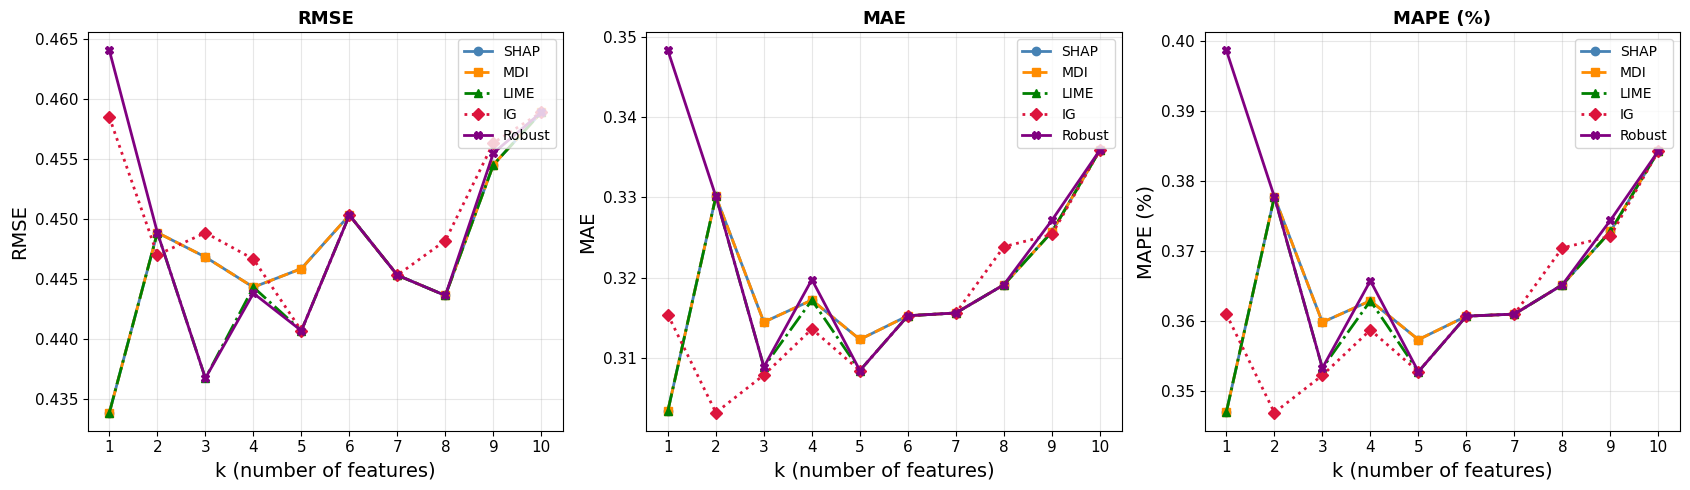

In [ ]:
plot_comparison(
    'RandomForest',
    {'SHAP': randomforest_res_shap, 'MDI': randomforest_res_mdi,
     'LIME': randomforest_res_lime, 'IG':   randomforest_res_ig, 'Robust': randomforest_res_robust},
    k_values,
)

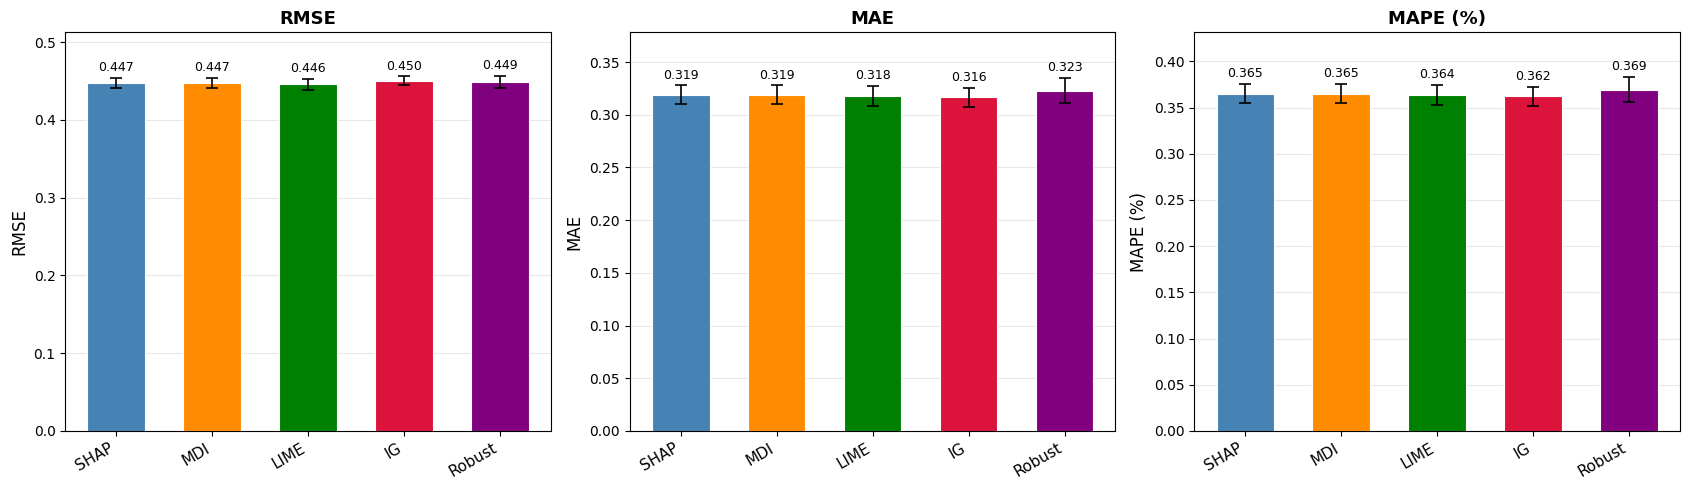

In [ ]:
plot_comparison_bar(
    'RandomForest',
    {'SHAP': randomforest_res_shap, 'MDI': randomforest_res_mdi,
     'LIME': randomforest_res_lime, 'IG':   randomforest_res_ig, 'RoSHAP': randomforest_res_robust},
    k_values,
)

---
## CatBoost

### CatBoost — SHAP

In [31]:
print('Computing SHAP ranking for CatBoost...')
catboost_shap = get_shap_ranking(MODELS['CatBoost'], X_train, y_train)
print('Top-10:')
catboost_shap.head(10)

Computing SHAP ranking for CatBoost...
Top-10:


,feature,importance
0,WAP156,195718.483449
1,WAP501,162535.586307
2,WAP155,161577.678346
3,WAP087,153705.184354
4,WAP051,124113.443912
5,WAP161,95464.937582
6,WAP052,86617.987091
7,WAP128,81828.514551
8,WAP117,79836.644624
9,WAP118,70710.563479


### CatBoost — Gain

In [32]:
print('Computing Gain ranking for CatBoost...')
catboost_gain = get_gain_ranking(MODELS['CatBoost'], X_train, y_train)
if catboost_gain is not None:
    print('Top-10:')
    display(catboost_gain.head(10))
else:
    print('Gain not supported for CatBoost')


Computing Gain ranking for CatBoost...
Top-10:


,feature,importance
0,WAP156,12.493021
1,WAP155,10.294366
2,WAP051,6.479001
3,WAP501,5.732501
4,WAP161,4.823999
5,WAP087,4.213769
6,WAP052,3.796562
7,WAP162,2.783239
8,WAP128,2.327651
9,WAP117,2.139412


### CatBoost — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [33]:
print('Computing LIME ranking for CatBoost...')
catboost_lime = get_lime_ranking(
    MODELS['CatBoost'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
catboost_lime.head(10)

Computing LIME ranking for CatBoost...
Top-10:


,feature,importance
0,WAP248,0.817276
1,WAP343,0.000000
2,WAP344,0.000000
3,WAP345,0.000000
4,WAP346,0.000000
5,WAP347,0.000000
6,WAP348,0.000000
7,WAP326,0.000000
8,WAP350,0.000000
9,WAP351,0.000000


### CatBoost — Robust

In [34]:
# top60 = catboost_shap['feature'].head(60).tolist()

In [13]:
cb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="regression",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=cb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):   1%|▏         | 7/500 [00:09<08:59,  1.09s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Bootstrap repeats (feature-agg):   2%|▏         | 8/500 [00:09<07:47,  1.05it/s]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Bootstrap repeats (feature-agg):   2%|▏         | 9/500 [00:10<06:38,  1.23it/s]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused 

In [35]:
filepath = shap_path + "/cb_uji.parquet"
# pd.concat(cb_boot_unscreen, ignore_index=True).to_parquet(
#     filepath, index=False, compression="zstd"
# )
# print("Saved!")

df_all = pd.read_parquet(filepath)
cb_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(cb_boot_unscreen)} bootstrap results")

Loaded 500 bootstrap results


In [36]:
cb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=cb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [37]:
tmp = cb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(100, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

catboost_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
catboost_robust.head(10)


,feature,importance
Rank,,
1,WAP155,206898.513232
2,WAP156,186090.907929
3,WAP501,164279.986739
4,WAP087,157984.051110
5,WAP051,135470.804608
6,WAP052,114047.150239
7,WAP496,112907.005047
8,WAP118,96219.646740
9,WAP161,95232.785230


### CatBoost — Evaluation & Comparison

Evaluating CatBoost — SHAP...
Evaluating CatBoost — Native...
Evaluating CatBoost — LIME...
Evaluating CatBoost — IG...
Evaluating CatBoost — Robust Bootstrap...


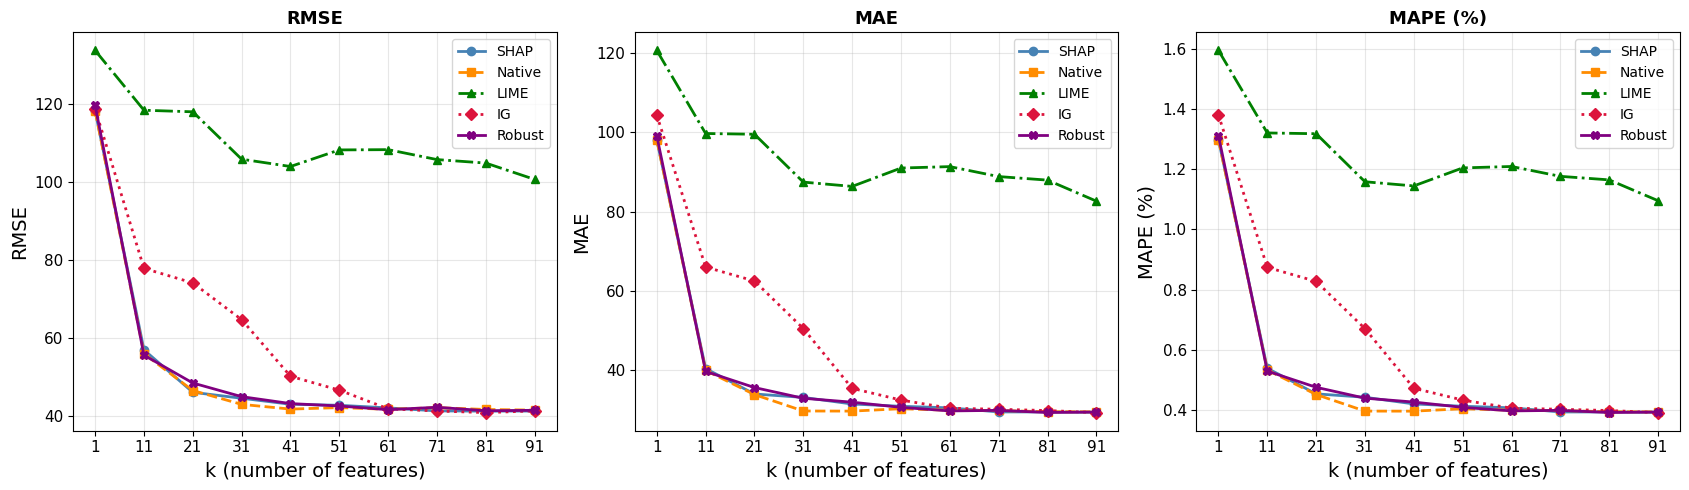

In [38]:
k_values = list(range(1, 101, 10))

print('Evaluating CatBoost — SHAP...')
catboost_res_shap = evaluate_topk(MODELS['CatBoost'], catboost_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating CatBoost — Native...')
catboost_res_native = evaluate_topk(MODELS['CatBoost'], catboost_gain, X_train, X_test, y_train, y_test, k_values) if catboost_gain is not None else None

print('Evaluating CatBoost — LIME...')
catboost_res_lime = evaluate_topk(MODELS['CatBoost'], catboost_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating CatBoost — IG...')
catboost_res_ig = evaluate_topk(MODELS['CatBoost'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating CatBoost — Robust Bootstrap...')
catboost_res_robust = evaluate_topk(MODELS['CatBoost'], catboost_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'CatBoost',
    {'SHAP': catboost_res_shap, 'Native': catboost_res_native,
     'LIME': catboost_res_lime, 'IG':   catboost_res_ig, 'Robust': catboost_res_robust},
    k_values,
)


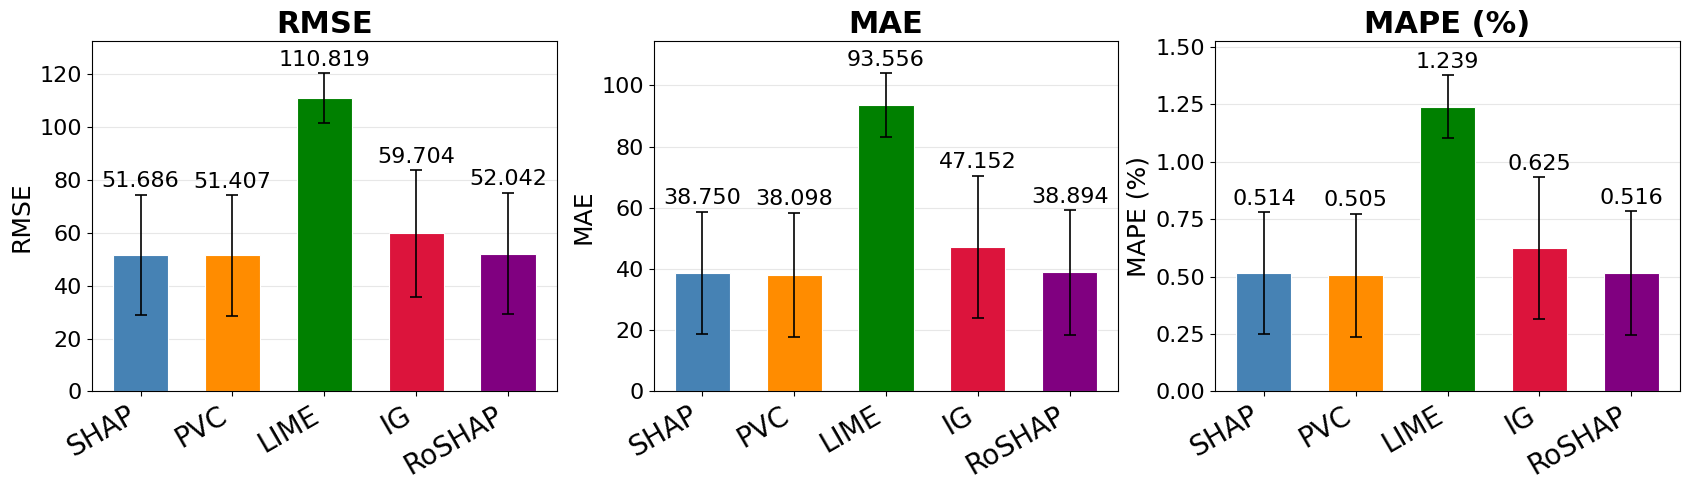

In [60]:
plot_comparison_bar(
    'CatBoost',
    {'SHAP': catboost_res_shap, 'PVC': catboost_res_native,
     'LIME': catboost_res_lime, 'IG':   catboost_res_ig, 'RoSHAP': catboost_res_robust},
    k_values,
)

---
## GradientBoosting

### GradientBoosting — SHAP

In [40]:
print('Computing SHAP ranking for GradientBoosting...')
gradientboosting_shap = get_shap_ranking(MODELS['GradientBoosting'], X_train, y_train)
print('Top-10:')
gradientboosting_shap.head(10)

Computing SHAP ranking for GradientBoosting...
Top-10:


,feature,importance
0,WAP155,208201.283268
1,WAP156,199574.963466
2,WAP051,166324.549011
3,WAP501,138345.809855
4,WAP087,136614.953970
5,WAP502,134544.773291
6,WAP496,119615.931250
7,WAP161,96093.020409
8,WAP099,78085.746071
9,WAP013,75786.440711


### GradientBoosting — Gain

In [41]:
print('Computing Gain ranking for GradientBoosting...')
gradientboosting_gain = get_gain_ranking(MODELS['GradientBoosting'], X_train, y_train)
if gradientboosting_gain is not None:
    print('Top-10:')
    display(gradientboosting_gain.head(10))
else:
    print('Gain not supported for GradientBoosting')


Computing Gain ranking for GradientBoosting...
Top-10:


,feature,importance
0,WAP156,0.125726
1,WAP155,0.119788
2,WAP051,0.103162
3,WAP496,0.056853
4,WAP161,0.056279
5,WAP502,0.054899
6,WAP501,0.049085
7,WAP162,0.037621
8,WAP087,0.035651
9,WAP052,0.023436


### GradientBoosting — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [42]:
print('Computing LIME ranking for GradientBoosting...')
gradientboosting_lime = get_lime_ranking(
    MODELS['GradientBoosting'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
gradientboosting_lime.head(10)

Computing LIME ranking for GradientBoosting...
Top-10:


,feature,importance
0,WAP248,1.082872
1,WAP343,0.000000
2,WAP344,0.000000
3,WAP345,0.000000
4,WAP346,0.000000
5,WAP347,0.000000
6,WAP348,0.000000
7,WAP326,0.000000
8,WAP350,0.000000
9,WAP351,0.000000


### GradientBoosting — Robust

In [22]:
# top60 = gradientboosting_shap['feature'].head(60).tolist()

In [23]:
gb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="regression",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=gb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [19:38<00:00,  2.36s/it]


In [43]:
filepath = shap_path + "/gb_uji.parquet"
# pd.concat(gb_boot_unscreen, ignore_index=True).to_parquet(
#     filepath, index=False, compression="zstd"
# )
# print("Saved!")

df_all = pd.read_parquet(filepath)
gb_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(gb_boot_unscreen)} bootstrap results")

Loaded 500 bootstrap results


In [44]:
gb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=gb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [45]:
tmp = gb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(100, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

gradientboosting_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
gradientboosting_robust.head(10)


,feature,importance
Rank,,
1,WAP156,243674.937520
2,WAP155,223174.388078
3,WAP087,183640.017054
4,WAP501,171653.795055
5,WAP051,152314.831561
6,WAP496,128782.302811
7,WAP161,114564.519601
8,WAP052,109523.769567
9,WAP099,95228.896883


### GradientBoosting — Evaluation & Comparison

In [46]:
k_values = list(range(1, 101, 10))

print('Evaluating GradientBoosting — SHAP...')
gradientboosting_res_shap = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating GradientBoosting — MDI...')
gradientboosting_res_mdi = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_gain, X_train, X_test, y_train, y_test, k_values) if gradientboosting_gain is not None else None

print('Evaluating GradientBoosting — LIME...')
gradientboosting_res_lime = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating GradientBoosting — IG...')
gradientboosting_res_ig = evaluate_topk(MODELS['GradientBoosting'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating GradientBoosting — Robust Bootstrap...')
gradientboosting_res_robust = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_robust, X_train, X_test, y_train, y_test, k_values)

Evaluating GradientBoosting — SHAP...
Evaluating GradientBoosting — MDI...
Evaluating GradientBoosting — LIME...
Evaluating GradientBoosting — IG...
Evaluating GradientBoosting — Robust Bootstrap...


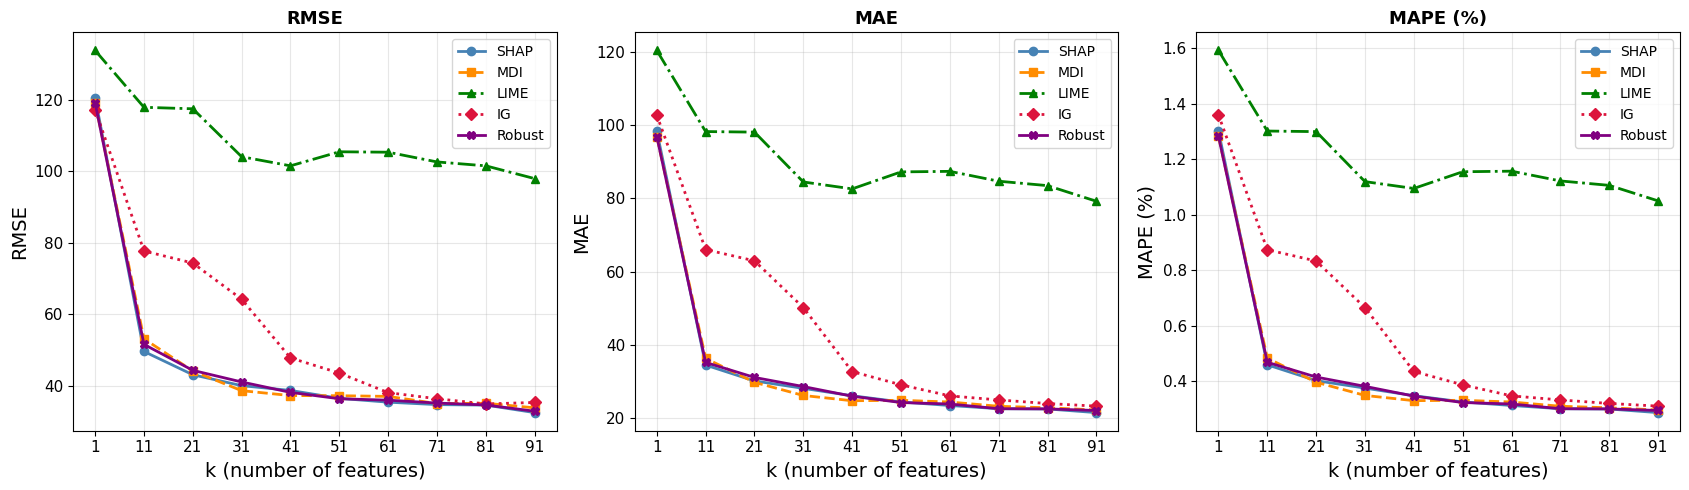

In [47]:
plot_comparison(
    'GradientBoosting',
    {'SHAP': gradientboosting_res_shap, 'MDI': gradientboosting_res_mdi,
     'LIME': gradientboosting_res_lime, 'IG':   gradientboosting_res_ig, 'Robust': gradientboosting_res_robust},
    k_values,
)

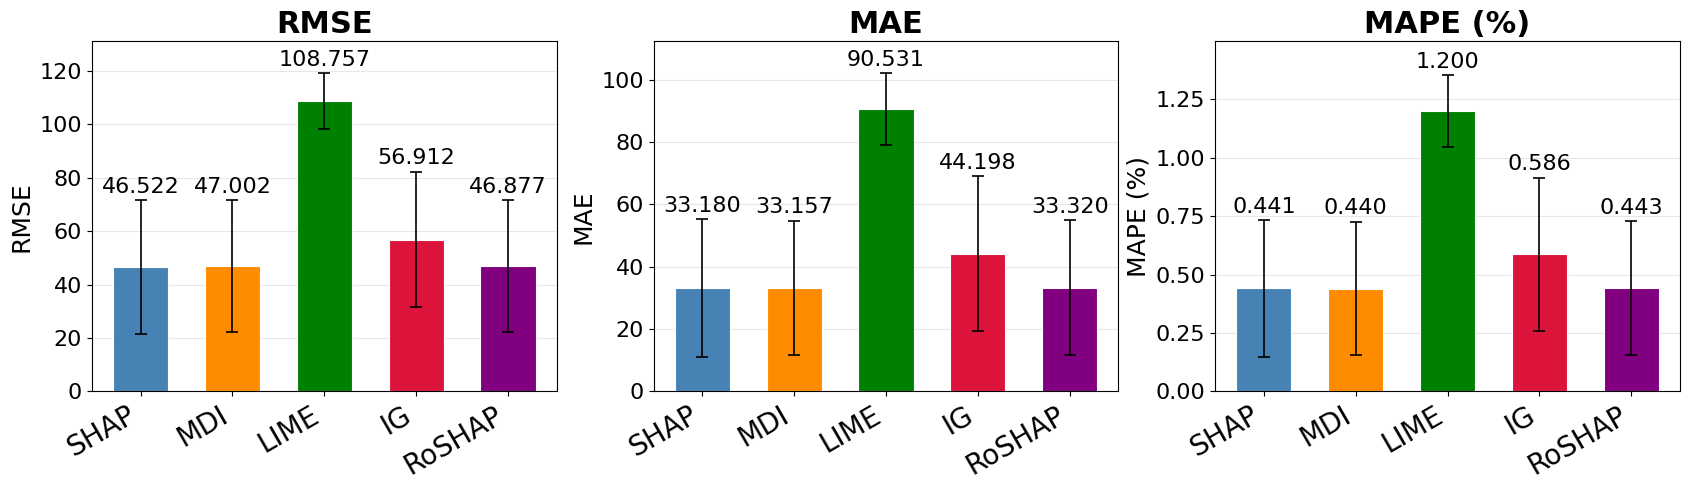

In [61]:
plot_comparison_bar(
    'GradientBoosting',
    {'SHAP': gradientboosting_res_shap, 'MDI': gradientboosting_res_mdi,
     'LIME': gradientboosting_res_lime, 'IG':   gradientboosting_res_ig, 'RoSHAP': gradientboosting_res_robust},
    k_values,
)

---
## Ridge

### Ridge — SHAP

In [49]:
print('Computing SHAP ranking for Ridge...')
logisticregression_shap = get_shap_ranking(MODELS['Ridge'], X_train, y_train)
print('Top-10:')
logisticregression_shap.head(10)

Computing SHAP ranking for Ridge...
Top-10:


,feature,importance
0,WAP155,140605.480262
1,WAP099,110850.533257
2,WAP039,103454.965928
3,WAP156,98057.441540
4,WAP051,80167.466673
5,WAP048,78237.833353
6,WAP040,75531.171921
7,WAP501,73520.602805
8,WAP118,67098.335216
9,WAP162,59585.797968


### Ridge — Gain (|Coef|)

In [50]:
print('Computing Gain ranking for Ridge...')
logisticregression_gain = get_gain_ranking(MODELS['Ridge'], X_train, y_train)
if logisticregression_gain is not None:
    print('Top-10:')
    display(logisticregression_gain.head(10))
else:
    print('Gain not supported for Ridge')

Computing Gain ranking for Ridge...
Top-10:


,feature,importance
0,WAP211,0.599315
1,WAP387,0.474932
2,WAP357,0.401741
3,WAP205,0.386555
4,WAP251,0.385342
5,WAP079,0.314257
6,WAP459,0.299307
7,WAP309,0.285418
8,WAP408,0.274725
9,WAP210,0.271563


### Ridge — LIME

In [51]:
print('Computing LIME ranking for Ridge...')
logisticregression_lime = get_lime_ranking(
    MODELS['Ridge'], X_train, y_train,
    n_samples=10,
    num_features=50,
)
print('Top-10:')
logisticregression_lime.head(10)

Computing LIME ranking for Ridge...
Top-10:


,feature,importance
0,WAP248,2.29625
1,WAP343,0.00000
2,WAP344,0.00000
3,WAP345,0.00000
4,WAP346,0.00000
5,WAP347,0.00000
6,WAP348,0.00000
7,WAP326,0.00000
8,WAP350,0.00000
9,WAP351,0.00000


### Ridge — Robust

In [52]:
# top60 = logisticregression_shap['feature'].head(60).tolist()

In [59]:
ridge_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="regression",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=ridge_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [01:20<00:00,  6.25it/s]


In [53]:
filepath = shap_path + "/ridge_uji.parquet"
# pd.concat(ridge_boot_unscreen, ignore_index=True).to_parquet(
#     filepath, index=False, compression="zstd"
# )
# print("Saved!")

df_all = pd.read_parquet(filepath)
ridge_boot_unscreen = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(ridge_boot_unscreen)} bootstrap results")

Loaded 500 bootstrap results


In [54]:
ridge_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=ridge_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [55]:
tmp = ridge_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"] * tmp["nonzero_median"] * tmp["SNR"]

top = tmp.nlargest(100, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"

ridge_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
ridge_robust.head(10)

,feature,importance
Rank,,
1,WAP155,143064.805887
2,WAP099,119748.287953
3,WAP039,104153.983335
4,WAP051,104031.685676
5,WAP048,101066.536081
6,WAP156,100530.995184
7,WAP162,94736.106785
8,WAP501,90441.308193
9,WAP161,77220.645478


### Ridge — Evaluation & Comparison

In [56]:
k_values = list(range(1, 101,10))

print('Evaluating Ridge — SHAP...')
ridge_res_shap = evaluate_topk(MODELS['Ridge'], logisticregression_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating Ridge — |Coef|...')
ridge_res_coef = evaluate_topk(MODELS['Ridge'], logisticregression_gain, X_train, X_test, y_train, y_test, k_values) if logisticregression_gain is not None else None

print('Evaluating Ridge — LIME...')
ridge_res_lime = evaluate_topk(MODELS['Ridge'], logisticregression_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating Ridge — IG...')
ridge_res_ig = evaluate_topk(MODELS['Ridge'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating Ridge — Robust Bootstrap...')
ridge_res_robust = evaluate_topk(MODELS['Ridge'], ridge_robust, X_train, X_test, y_train, y_test, k_values)

Evaluating Ridge — SHAP...
Evaluating Ridge — |Coef|...
Evaluating Ridge — LIME...
Evaluating Ridge — IG...
Evaluating Ridge — Robust Bootstrap...


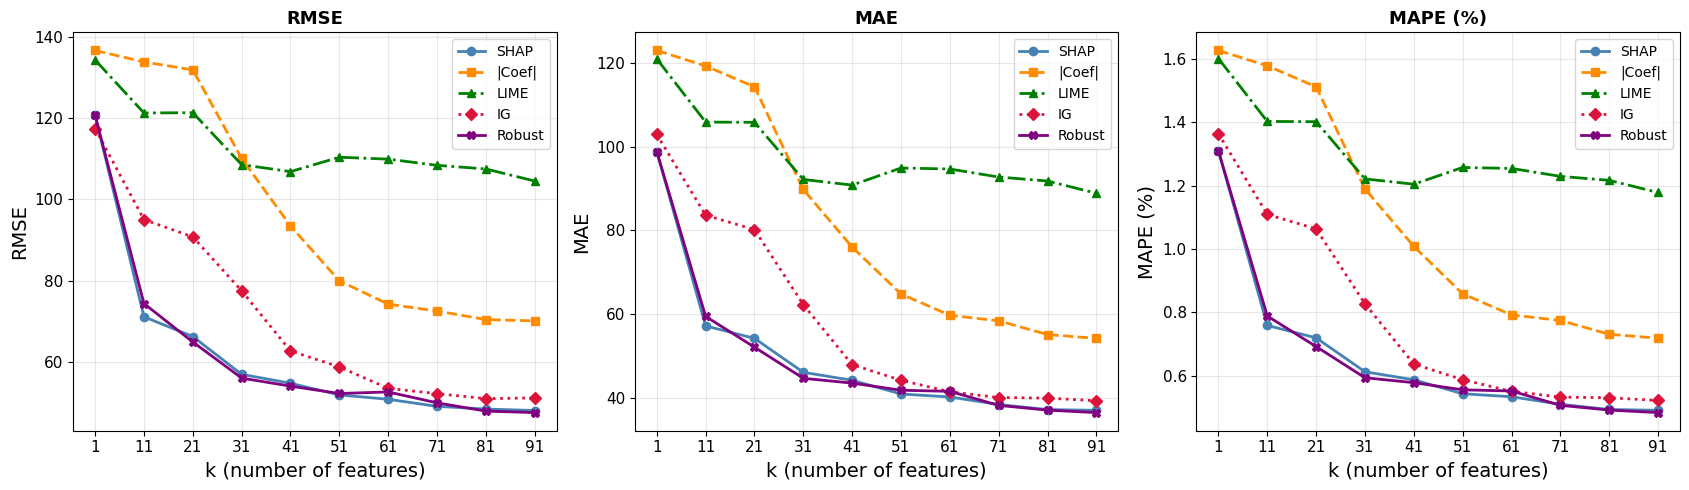

In [26]:
plot_comparison(
    'Ridge',
    {'SHAP': ridge_res_shap, '|Coef|': ridge_res_coef,
     'LIME': ridge_res_lime, 'IG': ridge_res_ig, 'Robust': ridge_res_robust},
    k_values,
)

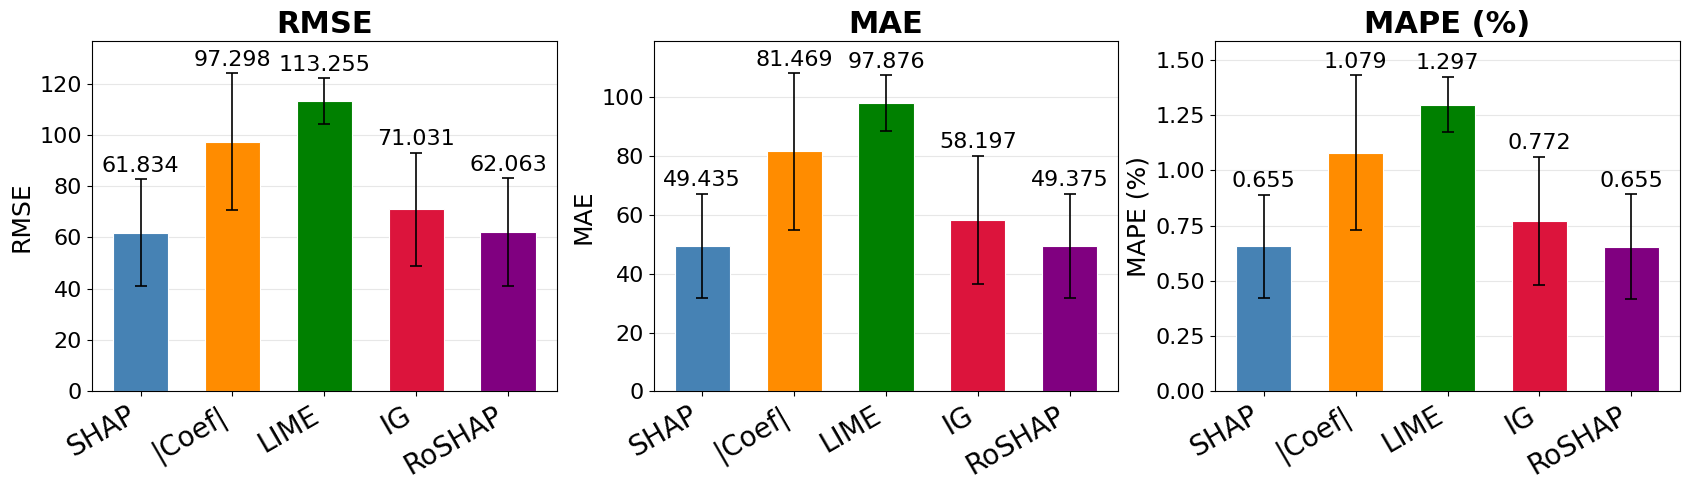

In [57]:
plot_comparison_bar(
    'Ridge',
    {'SHAP': ridge_res_shap, '|Coef|': ridge_res_coef,
     'LIME': ridge_res_lime, 'IG': ridge_res_ig, 'RoSHAP': ridge_res_robust},
    k_values,
)